In [1]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import seaborn as sns

In [2]:
# enable float64 precision
jax.config.update("jax_enable_x64", True)

# initialize JAX random key
seed = 42
key = random.PRNGKey(seed)

In [3]:
def inv_cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.inv(jax.scipy.linalg.toeplitz(cov0))

In [4]:
def inv_std(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    Cov = jax.scipy.linalg.toeplitz(cov0)
    L = jax.scipy.linalg.cholesky(Cov)
    return jax.scipy.linalg.inv(L)

In [5]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

In [77]:
def compare_plot(samples, x, y_true, y_noise, compare="true"):

    y_samples = tuple(my_model(s) for s in samples)
    y_mean, y_std = jft.mean_and_std(y_samples)

    snr = np.max(np.abs(y_noise))/np.sqrt(np.mean(y_noise[:-50]**2))
    print(np.sqrt(np.mean(y_noise[:-50]**2)))

    # calculate statistical measurements
    diff = y_mean - y_true
    rmse = diff/y_std #Root mean square

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # vertical lines
    # for j in range(2):
    #      for i in range(len(x)):
    #         axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    axes[0].fill_between(x, y_mean-y_std, y_mean+y_std, color="blue", alpha=0.5)
    axes[0].plot(x, y_true, label=compare, c="orange", zorder=10)
    axes[0].plot(x, y_noise, label="Noised data", c="red", zorder=0)
    axes[0].plot(x, y_mean, label=f"nifty mean", c="blue")
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray")

    axes[1].fill_between(x, diff-y_std, diff+y_std, color="blue", alpha=0.5)
    axes[1].plot(x, diff, c="blue")

    axes[1].set_ylabel(r"Residual")
    axes[1].set_ylim(0.0005, -0.0005)
    plt.xlabel(r"$t$ [ns]")

    plt.title(f"SNR={snr}")
    plt.show()

In [7]:
# measurement locations and data
t200 = np.load("data/time_200.npy")
d200 = np.load("data/true_trace_200.npy")
d200_noise = np.load("data/trace_200_simnoise.npy")

In [8]:
def fieldmaker(shape, distances, prefix, **args):
    cfm = jft.CorrelatedFieldMaker(prefix=f"{prefix}")
    cfm.set_amplitude_total_offset(
        offset_mean=args["offset_mean"], offset_std=args["offset_std"]
    )
    args.pop("offset_mean")
    args.pop("offset_std")
    cfm.add_fluctuations(
        shape=shape,
        distances=distances,
        **args,
    )
    cf_model = cfm.finalize()

    return cf_model, cfm.power_spectrum

In [55]:
class SignalModel(jft.Model):
    def __init__(self, cf_model, window_mean_pos_prior, window_std_prior, x_grid):
        self.cf_model = cf_model
        self.window_mean_pos_prior = window_mean_pos_prior
        self.window_std_prior = window_std_prior
        self.x_grid = x_grid

        super().__init__(init=
                         self.cf_model.init | self.window_mean_pos_prior.init | self.window_std_prior.init
                         )

    def gaussian_window(self, x_grid, x0, sigma):
        return jnp.exp(-(x_grid-x0)**2/(2*sigma**2))

    def __call__(self, x):
        return self.cf_model(x) * self.gaussian_window(self.x_grid, self.window_mean_pos_prior(x), self.window_std_prior(x))
        # return self.cf_model(x) * self.gaussian_window(self.x_grid, 3.1e2, 30.)

In [10]:
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

Inv_Cov = inv_cov(len(d200_noise), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(d200_noise), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
       260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320,
       325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385,
       390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450,
       455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515,
       520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580,
       585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645,
       650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710,
       715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775,
       780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840,
       845, 850, 855, 860, 865, 870, 875, 880, 885, 890, 895, 90

In [56]:
# likelihood
cf_kwargs = {
    "offset_mean": 0,
    "offset_std": (1.71e-4, 1e-5),
    "fluctuations": (1e-3, 1e-4),
    "loglogavgslope": (5., 1.5),
    "flexibility": (1.0, 1.0),
    "asperity": (1.0e-8, 1.0e-8),
    "prefix": "",
}

x0 = jft.NormalPrior(mean=3.1e2, std=1e-10, name='mean_pos_window', shape=(1,))
sigma = jft.NormalPrior(mean=30., std=1e-21, name='std_window', shape=(1,))

shape = 200
distances = 5e-9

cf_model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)

my_model = SignalModel(cf_model, x0, sigma, t200)

lh = jft.Gaussian(data=d200_noise, noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

key, subkey = random.split(key, 2)
init_pos = lh.init(subkey)
print("initial position: ", init_pos)
init_pos = jft.Vector(init_pos)
print("initial position vector: ", init_pos)

n_vi_iterations = 6
n_samples = 10
key, sampling_key = random.split(key, 2)

draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
)

kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

sample_mode = "linear_resample"

optimize_kl_args = dict(
    likelihood=lh,
    position_or_samples=init_pos,
    n_total_iterations=n_vi_iterations,
    n_samples=n_samples,
    key=sampling_key,
    draw_linear_kwargs=draw_linear_kwargs,
    kl_kwargs=kl_kwargs,
    sample_mode=sample_mode,
)

samples, state = jft.optimize_kl(**optimize_kl_args)

OPTIMIZE_KL: Starting 0001


initial position:  {'asperity': Array(1.10007036, dtype=float64), 'flexibility': Array(-0.18733046, dtype=float64), 'fluctuations': Array(0.10942154, dtype=float64), 'loglogavgslope': Array(-0.11779219, dtype=float64), 'mean_pos_window': Array([-1.26158464], dtype=float64), 'spectrum': Array([[ 1.26325804, -0.42956361],
       [-0.56588476,  0.16821651],
       [ 0.7203516 , -1.6665657 ],
       [-0.18949001, -0.42537955],
       [-0.52678104, -0.63524031],
       [ 1.14469099, -0.56458341],
       [-0.68653607, -0.9106846 ],
       [ 1.15566521, -1.48000909],
       [ 0.78226505,  1.67787625],
       [-0.4627013 , -1.35859329],
       [ 0.60998235,  0.05549088],
       [-0.23753161, -0.63634094],
       [-0.20532532,  0.67815834],
       [ 1.58530829,  1.79070108],
       [ 0.54952851, -0.80415852],
       [-0.42297131,  0.51173058],
       [-0.33991933, -1.00271709],
       [-0.09453693,  0.89885942],
       [ 1.16604659, -0.31005779],
       [-1.18320103,  0.56405721],
       [-0.34

N: Iteration Limit Reached
OPTIMIZE_KL: Iteration 0001 E:+2.9885e+02
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 35
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:    0.56±    0.28, avg:   -0.009±   0.025, #dof:    200'

OPTIMIZE_KL: Prior residual(s):
asperity                :: 'reduced Chi²:    0.44±    0.81, avg:   +8e-05±    0.67, #dof:      1'
flexibility             :: 'reduced Chi²: 1.3e+01±     8.9, avg:     +3.4±     1.3, #dof:      1'
fluctuations            :: 'reduced Chi²: 2.6e+01±     8.2, avg:     -5.0±    0.81, #dof:      1'
loglogavgslope          :: 'reduced Chi²:     5.0±     3.3, avg:     -2.1±    0.78, #dof:      1'
mean_pos_window         :: 'reduced Chi²:    0.89±    0.91, avg: -7.3e-05±    0.94, #dof:      1'
spectrum                :: 'reduced Chi²:     1.2±    0.12, avg:    -0.13±   0.067, #dof:    198'
std_window              :: 'reduced Chi²:     1.2±     1.1, avg: -3.9e-05±     1.1, #dof:     

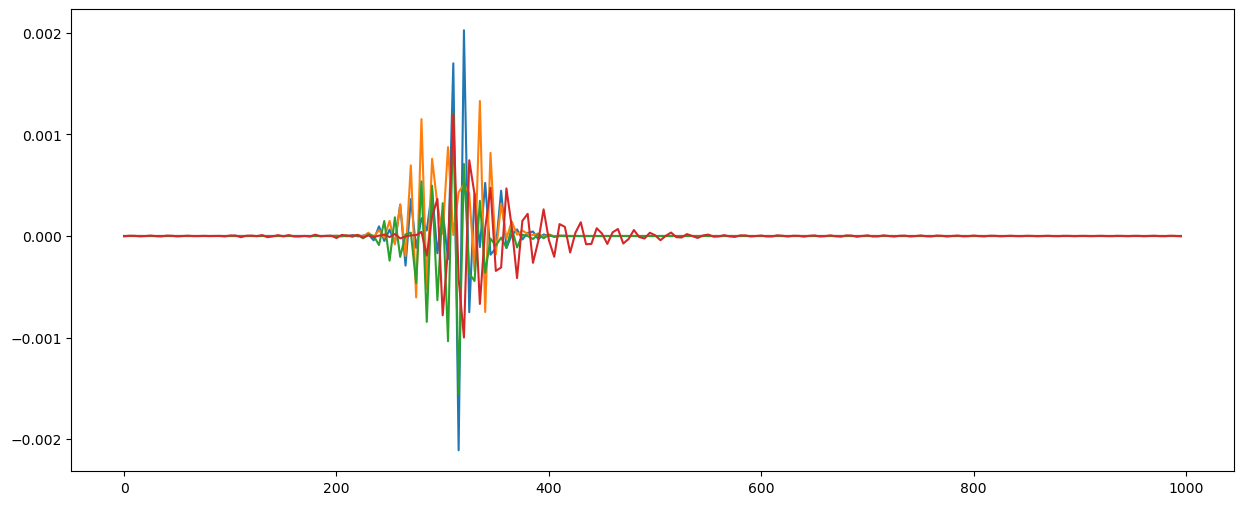

In [54]:
key, *subkeys = random.split(key, 4)
xi_samples = [jft.random_like(sk, my_model.domain) for sk in subkeys]

#  print(xi_samples[0]['spectrum'])

plt.figure(figsize=(15,6))
for i, xi in enumerate(xi_samples):
    plt.plot(t200, my_model(xi))
plt.plot(t200, d200)
plt.show()

In [52]:
a_samples = tuple(x0(s) for s in samples)
b_samples = tuple(sigma(s) for s in samples)
y_samples = tuple(my_model(s) for s in samples)
a_mean = jft.mean(a_samples)
b_mean = jft.mean(b_samples)
y_mean = jft.mean(y_samples)
print("mean of x0: ", a_mean)
print("mean of sigma: ", b_mean)


mean of x0:  [3.1e-07]
mean of sigma:  [3.e-08]


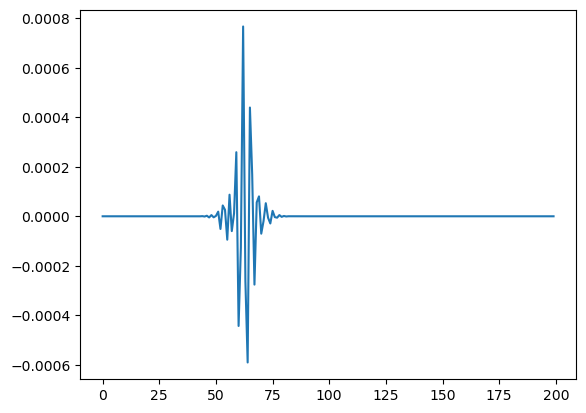

In [53]:
plt.plot(y_mean)
plt.show()

0.00019701597746762467


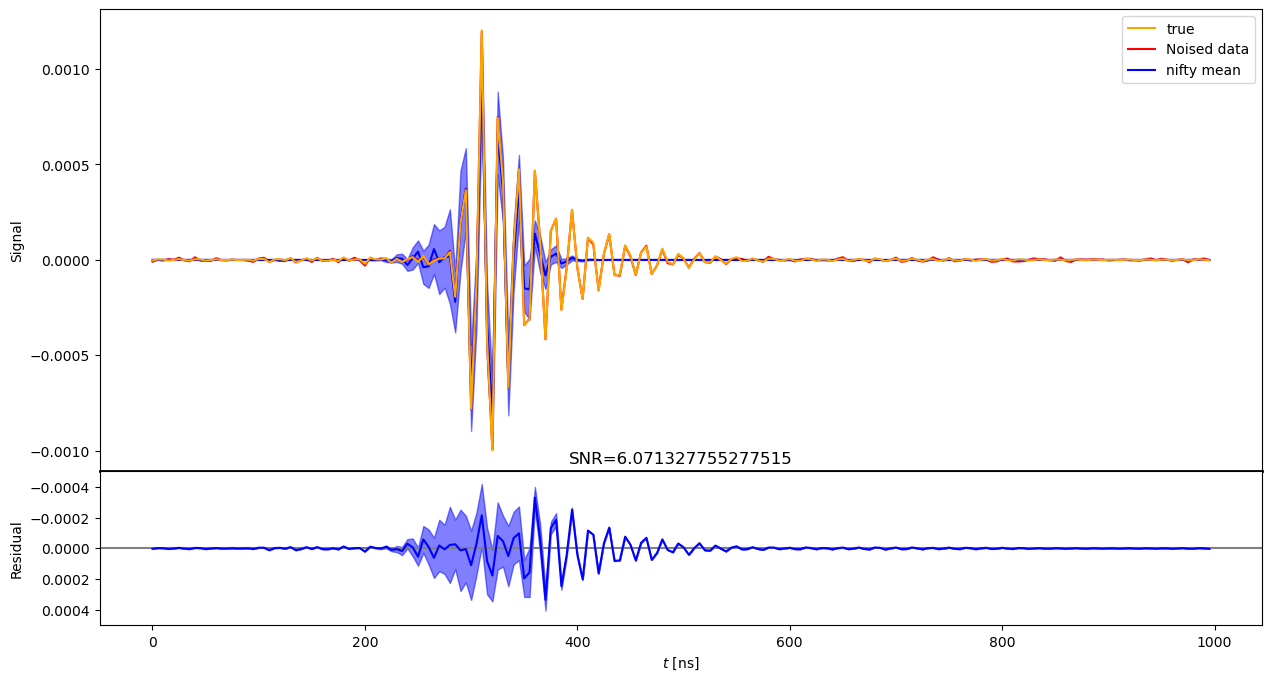

In [80]:
compare_plot(samples, t200, d200, d200_noise)